# Phase 4 — Resemblance Evaluation: Real vs. Synthetic GAF Images

**Project:** Battery SOH Estimation using GAF + C-W-DCGAN-GP + CNN-BiLSTM-Attention
**Input (from Phase 2):** `nasa_gaf_images.npz`, `nasa_gaf_labels_with_split.csv`, `nasa_gaf_minmax.pkl`
**Input (from Phase 3):** `cwdcgan_generator.keras`

**Goal of this notebook (Phase 4 only):**
1. Generate synthetic GAF images for each SOH bin using the trained C-W-DCGAN-GP generator.
2. Inverse-GAF transform synthetic images back to time-series signals.
3. Evaluate resemblance between real and synthetic data using:
   - **SSIM** (image-level structural similarity)
   - **MMD** (Maximum Mean Discrepancy — same metric as Opy's paper, lower = better)
   - **PCA** and **t-SNE** (visual cluster overlap — same as Opy's paper)
   - **KL Divergence** (distribution similarity per signal channel)
4. Visual comparison: real vs. synthetic V/I/T signals overlaid.

This notebook does **not** train any classifier — that is Phase 5.


## 1. Setup & Load Inputs

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy
from scipy.spatial.distance import cdist

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

# Phase 2 outputs
PHASE2_DIR = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output"
# Phase 3 outputs
PHASE3_DIR = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase3-output"
OUTPUT_DIR = "/kaggle/working"

# Load images + split labels
images_array = np.load(os.path.join(PHASE2_DIR, "nasa_gaf_images.npz"))["images"]
labels_df = pd.read_csv(os.path.join(PHASE2_DIR, "nasa_gaf_labels.csv"))

# Load split info from Phase 3
split_df = pd.read_csv(os.path.join(PHASE3_DIR, "nasa_gaf_labels_with_split.csv"))

# Load min/max for inverse GAF
with open(os.path.join(PHASE2_DIR, "nasa_gaf_minmax.pkl"), "rb") as f:
    gaf_minmax = pickle.load(f)

# Load trained generator
generator = tf.keras.models.load_model(os.path.join(PHASE3_DIR, "cwdcgan_generator.keras"))

print("Images:", images_array.shape)
print("Generator loaded.")
print(split_df["split"].value_counts())


I0000 00:00:1782910330.027333      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782910330.030402      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Images: (2544, 128, 128, 3)
Generator loaded.
split
train       2028
excluded     387
test         129
Name: count, dtype: int64


## 2. Extract Real Train-Split Images (by SOH Bin)

In [2]:
def soh_to_bin(soh):
    if soh >= 85: return 0   # fresh
    elif soh >= 70: return 1  # mid-life
    else: return 2            # aged

BIN_NAMES = {0: "fresh", 1: "mid-life", 2: "aged"}
NUM_CLASSES = 3
NOISE_DIM = 100

split_df["soh_bin"] = split_df["SOH_percent"].apply(soh_to_bin)

# Real images — train split, non-augmented only (clean originals)
real_mask = (split_df["split"] == "train") & (~split_df["is_augmented"])
real_df = split_df[real_mask].copy()
real_images = images_array[real_df.index.to_numpy()]

print("Real train images (clean, non-augmented):", real_images.shape)
print(real_df["soh_bin"].map(BIN_NAMES).value_counts())


Real train images (clean, non-augmented): (507, 128, 128, 3)
soh_bin
mid-life    256
fresh       207
aged         44
Name: count, dtype: int64


## 3. Generate Synthetic Images (same quantity as real per bin)

In [3]:
def generate_synthetic(generator, bin_id, n_samples, noise_dim=NOISE_DIM):
    noise = tf.random.normal([n_samples, noise_dim])
    labels = tf.constant([[bin_id]] * n_samples)
    synthetic = generator([noise, labels], training=False).numpy()
    return synthetic  # [-1, 1]


synthetic_by_bin = {}
real_by_bin = {}

for bin_id in range(NUM_CLASSES):
    real_subset = real_images[real_df["soh_bin"].to_numpy() == bin_id]
    n = len(real_subset)
    if n == 0:
        print(f"Warning: no real samples for bin {BIN_NAMES[bin_id]}, skipping.")
        continue
    syn = generate_synthetic(generator, bin_id, n)
    synthetic_by_bin[bin_id] = syn
    real_by_bin[bin_id] = real_subset
    print(f"Bin '{BIN_NAMES[bin_id]}': {n} real, {len(syn)} synthetic")


Bin 'fresh': 207 real, 207 synthetic
Bin 'mid-life': 256 real, 256 synthetic
Bin 'aged': 44 real, 44 synthetic


## 4. SSIM — Image-Level Structural Similarity

SSIM measures pixel-level structural fidelity between real and synthetic GAF images.
We compare each synthetic image to the mean of real images in the same bin (channel-wise).
A value close to 1 indicates high structural similarity.


In [4]:
ssim_results = {}

for bin_id in real_by_bin:
    real = real_by_bin[bin_id]          # [-1,1], shape [N, 128, 128, 3]
    syn  = synthetic_by_bin[bin_id]

    # Rescale to [0,1] for SSIM
    real_01 = (real + 1) / 2
    syn_01  = (syn  + 1) / 2

    # Compute SSIM for each synthetic vs mean real image in this bin
    mean_real = real_01.mean(axis=0)
    scores = [ssim(mean_real, s, channel_axis=-1, data_range=1.0) for s in syn_01]
    ssim_results[BIN_NAMES[bin_id]] = np.mean(scores)
    print(f"SSIM [{BIN_NAMES[bin_id]}]: {np.mean(scores):.4f} (mean over {len(scores)} synthetic samples)")

print()
print("SSIM > 0.5 is generally considered good structural similarity for GAN-generated images.")


SSIM [fresh]: 0.8283 (mean over 207 synthetic samples)
SSIM [mid-life]: 0.7861 (mean over 256 synthetic samples)
SSIM [aged]: 0.8408 (mean over 44 synthetic samples)

SSIM > 0.5 is generally considered good structural similarity for GAN-generated images.


## 5. MMD — Maximum Mean Discrepancy

MMD measures how close the real and synthetic distributions are in a high-dimensional feature space.
Lower MMD = better. We use the RBF (Gaussian) kernel, same as Opy's paper.


In [5]:
def rbf_kernel(X, Y, sigma=1.0):
    XX = cdist(X, X, "sqeuclidean")
    YY = cdist(Y, Y, "sqeuclidean")
    XY = cdist(X, Y, "sqeuclidean")
    kXX = np.exp(-XX / (2 * sigma ** 2))
    kYY = np.exp(-YY / (2 * sigma ** 2))
    kXY = np.exp(-XY / (2 * sigma ** 2))
    return kXX.mean() + kYY.mean() - 2 * kXY.mean()


def flatten_images(imgs):
    return imgs.reshape(len(imgs), -1)

mmd_results = {}

for bin_id in real_by_bin:
    real_flat = flatten_images(real_by_bin[bin_id])
    syn_flat  = flatten_images(synthetic_by_bin[bin_id])

    # Subsample if large (MMD is O(n^2))
    n = min(100, len(real_flat), len(syn_flat))
    idx_r = np.random.choice(len(real_flat), n, replace=False)
    idx_s = np.random.choice(len(syn_flat),  n, replace=False)

    # Use PCA to reduce dimensionality before MMD (same approach as literature)
    pca = PCA(n_components=50, random_state=42)
    combined = np.vstack([real_flat[idx_r], syn_flat[idx_s]])
    reduced = pca.fit_transform(combined)
    real_reduced, syn_reduced = reduced[:n], reduced[n:]

    mmd = rbf_kernel(real_reduced, syn_reduced)
    mmd_results[BIN_NAMES[bin_id]] = mmd
    print(f"MMD [{BIN_NAMES[bin_id]}]: {mmd:.6f}")

print()
print("MMD close to 0 indicates real and synthetic distributions are similar.")
print("For reference, Opy's paper reported MMD ≈ 0.015 on the MIT dataset.")


MMD [fresh]: 0.021336
MMD [mid-life]: 0.020879
MMD [aged]: 0.048354

MMD close to 0 indicates real and synthetic distributions are similar.
For reference, Opy's paper reported MMD ≈ 0.015 on the MIT dataset.


## 6. PCA Visualization — Real vs. Synthetic Feature Space

If real and synthetic clusters overlap significantly, the generator has captured the data distribution.


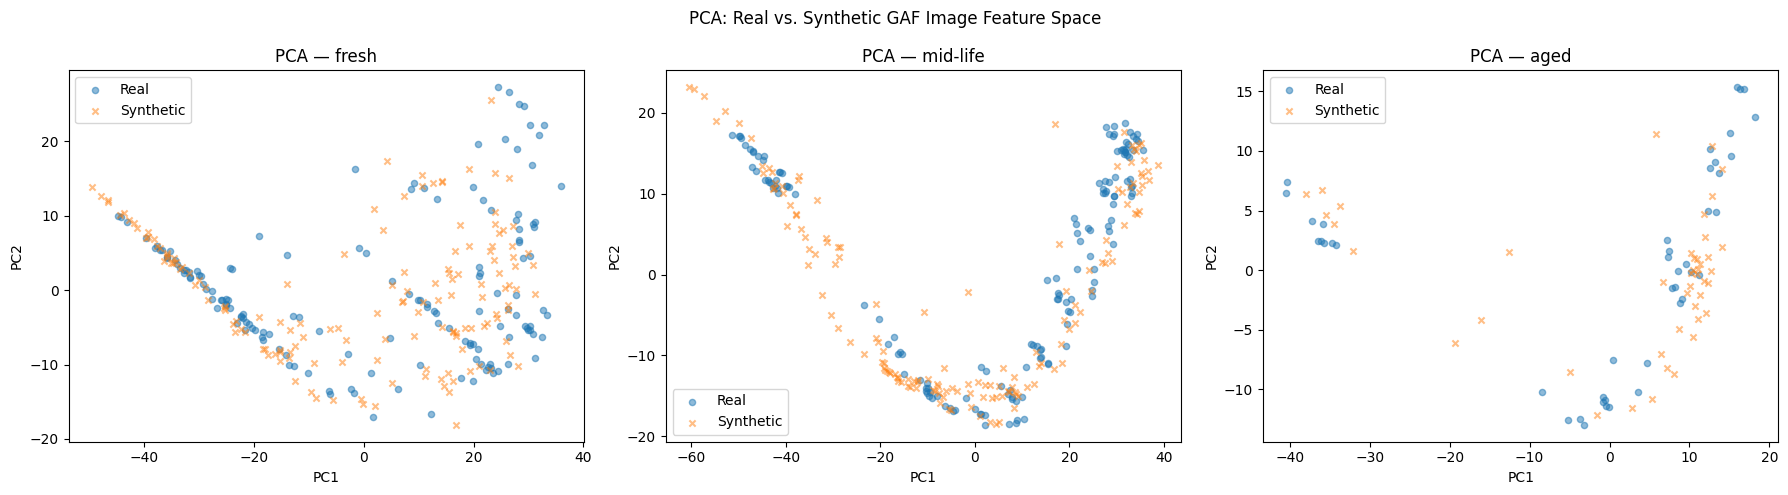

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))

for bin_id in real_by_bin:
    ax = axes[bin_id]
    real_flat = flatten_images(real_by_bin[bin_id])
    syn_flat  = flatten_images(synthetic_by_bin[bin_id])

    n = min(150, len(real_flat), len(syn_flat))
    combined = np.vstack([real_flat[:n], syn_flat[:n]])

    pca = PCA(n_components=2, random_state=42)
    reduced = pca.fit_transform(combined)

    ax.scatter(reduced[:n, 0], reduced[:n, 1], alpha=0.5, label="Real", s=20)
    ax.scatter(reduced[n:, 0], reduced[n:, 1], alpha=0.5, label="Synthetic", s=20, marker="x")
    ax.set_title(f"PCA — {BIN_NAMES[bin_id]}")
    ax.legend()
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.suptitle("PCA: Real vs. Synthetic GAF Image Feature Space")
plt.tight_layout()
plt.show()


## 7. t-SNE Visualization — Real vs. Synthetic

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


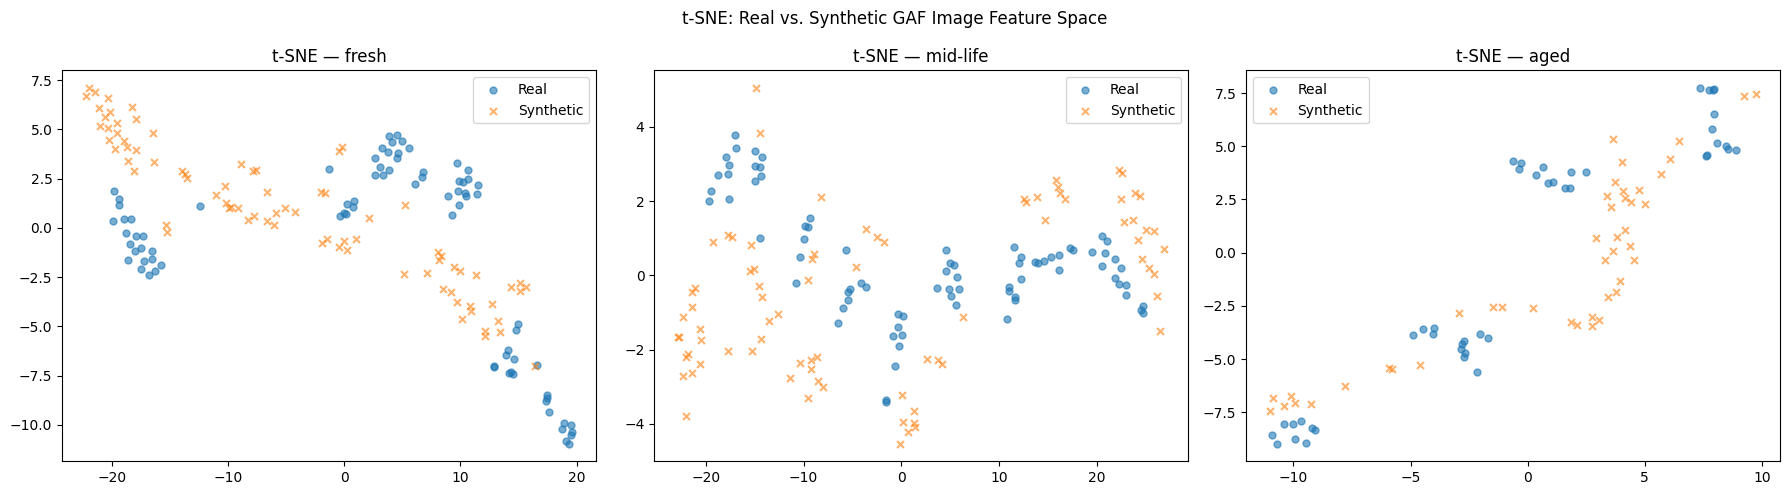

In [7]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))

for bin_id in real_by_bin:
    ax = axes[bin_id]
    real_flat = flatten_images(real_by_bin[bin_id])
    syn_flat  = flatten_images(synthetic_by_bin[bin_id])

    n = min(80, len(real_flat), len(syn_flat))  # t-SNE is slow; keep small

    # First reduce with PCA, then t-SNE
    combined = np.vstack([real_flat[:n], syn_flat[:n]])
    pca = PCA(n_components=30, random_state=42)
    reduced_pca = pca.fit_transform(combined)

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(20, n//2), n_iter=500)
    reduced = tsne.fit_transform(reduced_pca)

    ax.scatter(reduced[:n, 0], reduced[:n, 1], alpha=0.6, label="Real", s=25)
    ax.scatter(reduced[n:, 0], reduced[n:, 1], alpha=0.6, label="Synthetic", s=25, marker="x")
    ax.set_title(f"t-SNE — {BIN_NAMES[bin_id]}")
    ax.legend()

plt.suptitle("t-SNE: Real vs. Synthetic GAF Image Feature Space")
plt.tight_layout()
plt.show()


## 8. KL Divergence — Per-Channel Signal Distribution

After inverse-GAF transforming synthetic images back to V/I/T signals, we compare
the per-channel value distributions between real and synthetic using KL divergence.
Lower KL = more similar distributions.


In [8]:
def inverse_gasf_from_image(image_channel, min_val, max_val):
    """Reconstruct 1D signal from a single-channel GASF image (128x128)."""
    diag = np.clip(np.diag(image_channel), -1.0, 1.0)
    phi = 0.5 * np.arccos(diag)
    scaled = np.cos(phi)
    return scaled * (max_val - min_val) + min_val


def kl_div_signals(real_sigs, syn_sigs, n_bins=50):
    """KL divergence between real and synthetic signal value distributions."""
    all_vals = np.concatenate([real_sigs, syn_sigs])
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), n_bins + 1)
    p, _ = np.histogram(real_sigs, bins=bin_edges, density=True)
    q, _ = np.histogram(syn_sigs,  bins=bin_edges, density=True)
    p = p + 1e-10; q = q + 1e-10
    return float(entropy(p, q))


CHANNEL_NAMES = ["Voltage", "Current", "Temperature"]
kl_results = {}

for bin_id in real_by_bin:
    real_imgs = real_by_bin[bin_id]   # [N, 128, 128, 3]
    syn_imgs  = synthetic_by_bin[bin_id]

    # Use fixed reference min/max from first real battery (B0005), first cycle
    ref_battery = "B0005"
    ref_cycle = list(gaf_minmax[ref_battery].keys())[0]
    ref_minmax = gaf_minmax[ref_battery][ref_cycle]

    kl_per_channel = {}
    for ch, name in enumerate(CHANNEL_NAMES):
        channel_key = name.lower()
        min_v, max_v = ref_minmax[channel_key]

        real_sigs = np.array([inverse_gasf_from_image(img[:, :, ch], min_v, max_v) for img in real_imgs]).flatten()
        syn_sigs  = np.array([inverse_gasf_from_image(img[:, :, ch], min_v, max_v) for img in syn_imgs]).flatten()
        kl = kl_div_signals(real_sigs, syn_sigs)
        kl_per_channel[name] = kl

    kl_results[BIN_NAMES[bin_id]] = kl_per_channel
    print(f"KL [{BIN_NAMES[bin_id]}]: V={kl_per_channel['Voltage']:.4f}, I={kl_per_channel['Current']:.4f}, T={kl_per_channel['Temperature']:.4f}")


KL [fresh]: V=0.1132, I=1.9527, T=0.1225
KL [mid-life]: V=0.0629, I=1.8041, T=0.4796
KL [aged]: V=0.4409, I=1.7506, T=0.8162


## 9. Visual Comparison: Real vs. Synthetic Signals (Voltage, Current, Temperature)

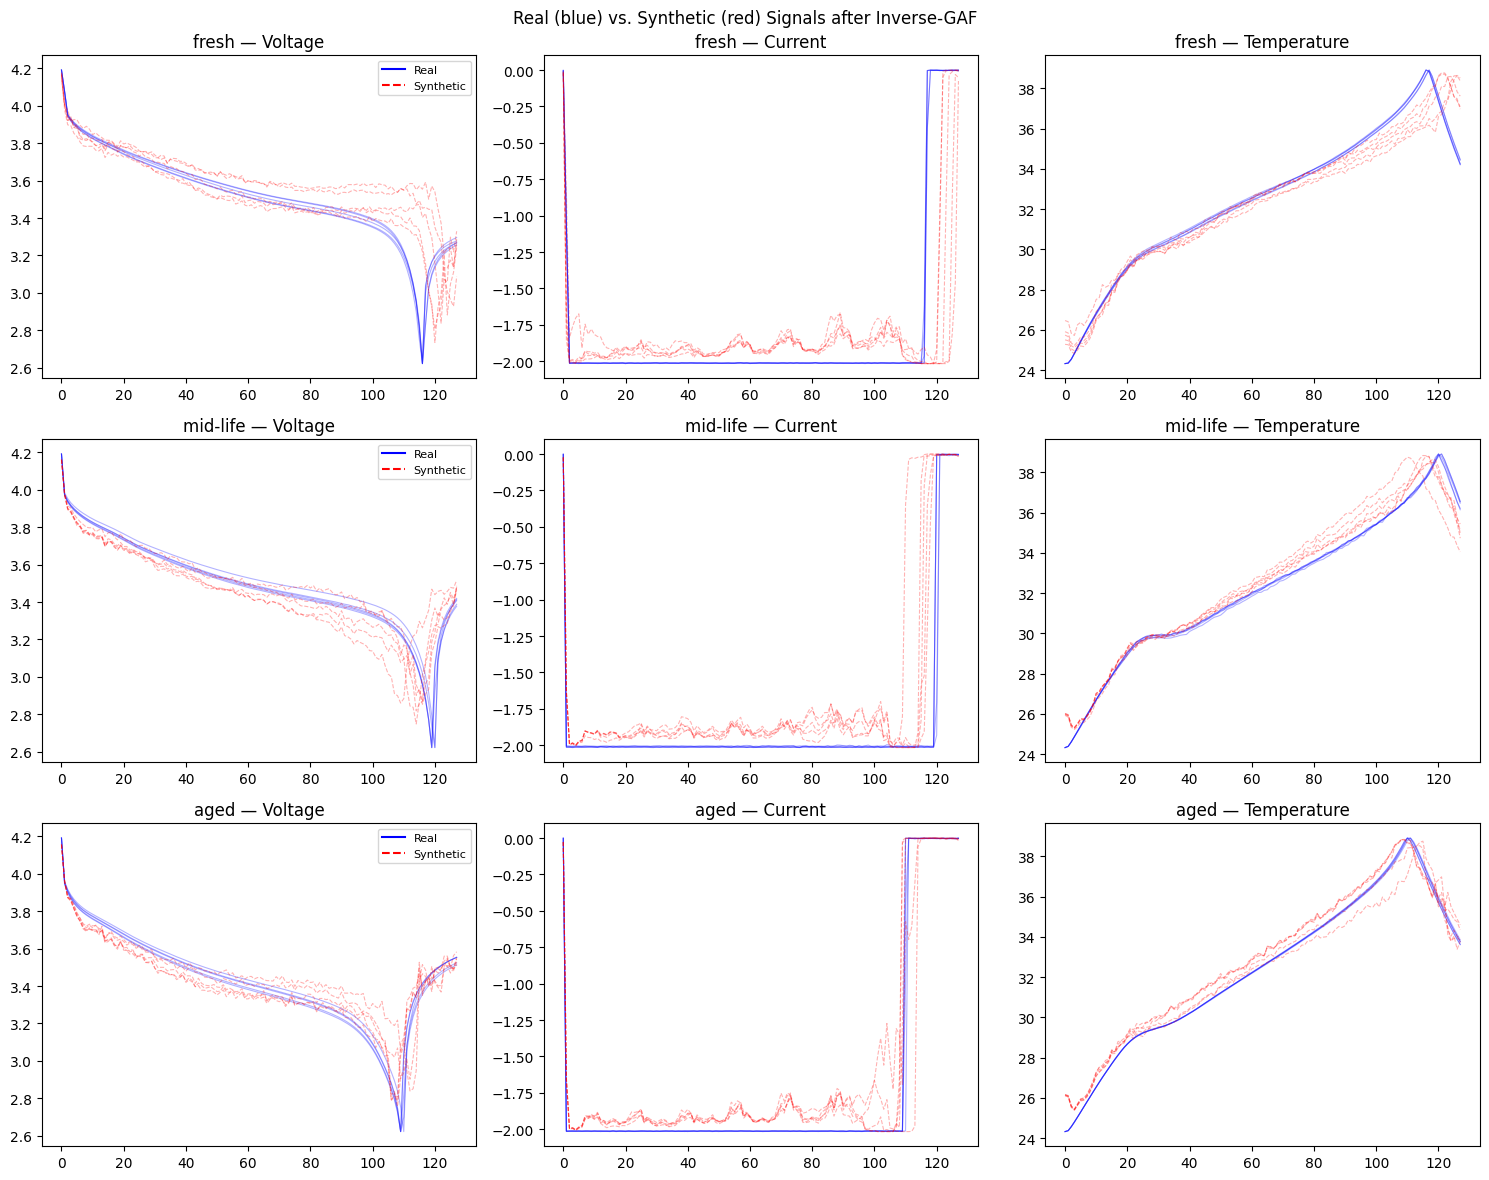

In [9]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(15, 12))

for bin_id in real_by_bin:
    real_imgs = real_by_bin[bin_id]
    syn_imgs  = synthetic_by_bin[bin_id]

    ref_battery = "B0005"
    ref_cycle = list(gaf_minmax[ref_battery].keys())[0]
    ref_minmax = gaf_minmax[ref_battery][ref_cycle]

    for ch, name in enumerate(CHANNEL_NAMES):
        channel_key = name.lower()
        min_v, max_v = ref_minmax[channel_key]
        ax = axes[bin_id][ch]

        for img in real_imgs[:5]:
            sig = inverse_gasf_from_image(img[:, :, ch], min_v, max_v)
            ax.plot(sig, color="blue", alpha=0.3, linewidth=0.8)
        for img in syn_imgs[:5]:
            sig = inverse_gasf_from_image(img[:, :, ch], min_v, max_v)
            ax.plot(sig, color="red", alpha=0.3, linewidth=0.8, linestyle="--")

        ax.set_title(f"{BIN_NAMES[bin_id]} — {name}")
        if ch == 0:
            ax.plot([], color="blue", label="Real"); ax.plot([], color="red", linestyle="--", label="Synthetic")
            ax.legend(fontsize=8)

plt.suptitle("Real (blue) vs. Synthetic (red) Signals after Inverse-GAF")
plt.tight_layout()
plt.show()


## 10. Summary Table

In [10]:
rows = []
for bin_name in BIN_NAMES.values():
    if bin_name not in ssim_results:
        continue
    rows.append({
        "SOH Bin": bin_name,
        "SSIM": round(ssim_results[bin_name], 4),
        "MMD": round(mmd_results[bin_name], 6),
        "KL (Voltage)": round(kl_results[bin_name]["Voltage"], 4),
        "KL (Current)": round(kl_results[bin_name]["Current"], 4),
        "KL (Temperature)": round(kl_results[bin_name]["Temperature"], 4),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(OUTPUT_DIR, "phase4_resemblance_results.csv"), index=False)
print("\nSaved: phase4_resemblance_results.csv")
print("\nPhase 4 complete.")


 SOH Bin   SSIM      MMD  KL (Voltage)  KL (Current)  KL (Temperature)
   fresh 0.8283 0.021336        0.1132        1.9527            0.1225
mid-life 0.7861 0.020879        0.0629        1.8041            0.4796
    aged 0.8408 0.048354        0.4409        1.7506            0.8162

Saved: phase4_resemblance_results.csv

Phase 4 complete.


---
### How to interpret these results

- **SSIM** closer to 1 → synthetic images structurally similar to real GAF images.
- **MMD** closer to 0 → synthetic and real distributions overlap well (Opy's paper: ~0.015 on MIT dataset).
- **KL Divergence** closer to 0 → per-channel signal distributions match closely.
- **PCA/t-SNE** → overlapping clusters mean the generator captured real data structure.

If results look reasonable here, proceed to Phase 5 where the downstream SOH regressor
(CNN-BiLSTM-Attention) is trained in three stages: real-only / TSTR / augmented.
